# AI Impact on Jobs & Layoff Risk — EDA
### Exploratory Data Analysis

This notebook walks through a **complete EDA workflow** for a dataset exploring how AI adoption is reshaping the workforce and influencing layoff risk.

**What we'll cover:**

1. **Import Libraries** — set up our tools
2. **Load the Dataset** — read the CSV and take a first look
3. **Data Overview** — shape, columns, dtypes, nulls, duplicates, statistics
4. **EDA** — 16 visualisations covering distributions, relationships, and comparisons
5. **Key Takeaways** — what the data tells us

**Target variable:** `Layoff_Risk` — three classes: *Low*, *Medium*, *High*


## 1. Import Libraries

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("All libraries imported successfully!")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

All libraries imported successfully!
/kaggle/input/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv


## 2. Load the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/shivasingh4945/ai-impact-on-jobs-and-layoff-risk-dataset/ai-impact-jobs-layoff-risk-dataset.csv")
print(f"Dataset loaded  →  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")


Dataset loaded  →  20,000 rows  ×  16 columns


## 3. Data Overview

### 3.1 First Five Rows
A quick glance to confirm the data loaded correctly.

In [3]:
df.head()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


### 3.2 Last Five Rows
Checking the tail ensures there's no junk at the end.

In [4]:
df.tail()

,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
19995,56,Bachelor's,10,Retail,Sales Associate,Small,Entry,29,62,44,Low,0,4,16,0,Medium
19996,43,Bachelor's,9,Manufacturing,Production Supervisor,Medium,Entry,87,20,20,High,9,23,77,67,High
19997,28,High School,7,Telecom,Support Specialist,Medium,Entry,91,2,49,Medium,2,14,55,10,High
19998,46,Bachelor's,3,Manufacturing,Quality Engineer,Medium,Senior,76,40,89,Medium,3,13,66,5,Medium
19999,36,Bachelor's,5,Retail,Store Manager,Medium,Mid,45,65,75,Low,1,0,30,8,Medium


### 3.3 Shape

In [5]:
print("Shape:", df.shape)
print(f"  → {df.shape[0]:,} employees,  {df.shape[1]} features")


Shape: (20000, 16)
  → 20,000 employees,  16 features


### 3.4 Column Names

In [6]:
print(df.columns.tolist())

['Age', 'Education_Level', 'Years_of_Experience', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'AI_Adoption_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours', 'Layoff_Risk']


### 3.5 Data Types
`object`/`str` columns are categorical; everything else is numeric.

In [7]:
df.dtypes

Age                            int64
Education_Level               object
Years_of_Experience            int64
Industry                      object
Job_Role                      object
Company_Size                  object
Job_Level                     object
Routine_Task_Percentage        int64
Creativity_Requirement         int64
Human_Interaction_Level        int64
AI_Adoption_Level             object
Number_of_AI_Tools_Used        int64
AI_Usage_Hours_Per_Week        int64
Tasks_Automated_Percentage     int64
AI_Training_Hours              int64
Layoff_Risk                   object
dtype: object

### 3.6 Detailed Info
`df.info()` shows data types, non-null counts, and memory usage at a glance.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         20000 non-null  int64 
 1   Education_Level             20000 non-null  object
 2   Years_of_Experience         20000 non-null  int64 
 3   Industry                    20000 non-null  object
 4   Job_Role                    20000 non-null  object
 5   Company_Size                20000 non-null  object
 6   Job_Level                   20000 non-null  object
 7   Routine_Task_Percentage     20000 non-null  int64 
 8   Creativity_Requirement      20000 non-null  int64 
 9   Human_Interaction_Level     20000 non-null  int64 
 10  AI_Adoption_Level           20000 non-null  object
 11  Number_of_AI_Tools_Used     20000 non-null  int64 
 12  AI_Usage_Hours_Per_Week     20000 non-null  int64 
 13  Tasks_Automated_Percentage  20000 non-null  in

### 3.7 Missing Values
Ideally we want 0 nulls everywhere.

In [9]:
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts)
print(f"\nTotal missing values: {null_counts.sum()}")


Null values per column:
Age                           0
Education_Level               0
Years_of_Experience           0
Industry                      0
Job_Role                      0
Company_Size                  0
Job_Level                     0
Routine_Task_Percentage       0
Creativity_Requirement        0
Human_Interaction_Level       0
AI_Adoption_Level             0
Number_of_AI_Tools_Used       0
AI_Usage_Hours_Per_Week       0
Tasks_Automated_Percentage    0
AI_Training_Hours             0
Layoff_Risk                   0
dtype: int64

Total missing values: 0


### 3.8 Duplicate Rows
Duplicates can distort analysis. We check for and drop them if found.

In [10]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
if dupes > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found — dataset is clean!")


Duplicate rows: 0
No duplicates found — dataset is clean!


### 3.9 Statistical Summary
`describe()` gives count, mean, std, min, quartiles, and max for every numeric column. Useful for spotting outliers.

In [11]:
df.describe().round(2)

,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00
mean,40.36,7.27,51.89,47.79,60.06,2.46,6.77,37.23,12.62
std,11.53,4.72,24.44,26.10,22.27,2.10,6.09,20.00,13.55
min,21.00,0.00,10.00,0.00,20.00,0.00,0.00,4.00,0.00
25%,30.00,4.00,31.00,27.00,41.00,1.00,2.00,21.00,4.00
50%,40.00,7.00,52.00,48.00,62.00,2.00,5.00,35.00,8.00
75%,50.00,11.00,73.00,69.00,79.00,4.00,10.00,51.00,18.00
max,60.00,32.00,94.00,100.00,99.00,10.00,30.00,93.00,79.00


### 3.10 Unique Values in Categorical Columns
Understand distinct categories before visualising.

In [12]:
cat_cols = ['Education_Level', 'Industry', 'Job_Role', 'Company_Size',
           'Job_Level', 'AI_Adoption_Level', 'Layoff_Risk']

for col in cat_cols:
    print(f"{col:25s}: {df[col].unique().tolist()}")


Education_Level          : ["Master's", "Bachelor's", 'High School', 'PhD']
Industry                 : ['Finance', 'Manufacturing', 'Retail', 'Telecom', 'IT', 'Logistics', 'Healthcare', 'Education']
Job_Role                 : ['Accountant', 'Production Supervisor', 'Store Manager', 'Auditor', 'Network Engineer', 'Software Engineer', 'ML Engineer', 'Inventory Analyst', 'Dispatcher', 'Health Analyst', 'Support Specialist', 'Sales Associate', 'Academic Coordinator', 'Financial Analyst', 'Operator', 'Research Assistant', 'Quality Engineer', 'Teacher', 'Warehouse Manager', 'Supply Chain Analyst', 'Operations Analyst', 'Medical Assistant', 'Nurse', 'Data Analyst']
Company_Size             : ['Medium', 'Small', 'Large']
Job_Level                : ['Entry', 'Senior', 'Mid']
AI_Adoption_Level        : ['Medium', 'Low', 'High']
Layoff_Risk              : ['High', 'Low', 'Medium']


### 3.11 Value Counts — Target Variable
How balanced is our target `Layoff_Risk`?

In [13]:
print(df['Layoff_Risk'].value_counts())
print()
print(df['Layoff_Risk'].value_counts(normalize=True).round(3) * 100, "  (% share)")


Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64

Layoff_Risk
High      34.0
Low       33.0
Medium    33.0
Name: proportion, dtype: float64   (% share)


## 4. Exploratory Data Analysis (EDA)

We create **16 visualisations** to understand distributions, relationships, and comparisons.
Each plot has a numbered title for easy reference.


In [14]:
# Helper: call after every plot
def show():
    plt.tight_layout()
    plt.show()

# Consistent colour order for Layoff_Risk
RISK_ORDER  = ['Low', 'Medium', 'High']
RISK_COLORS = ['#4CAF50', '#FF9800', '#F44336']

plot_no = 1


### 4.1 Distribution of Layoff Risk (Target Variable)
A count plot to see how many employees fall into each risk category.

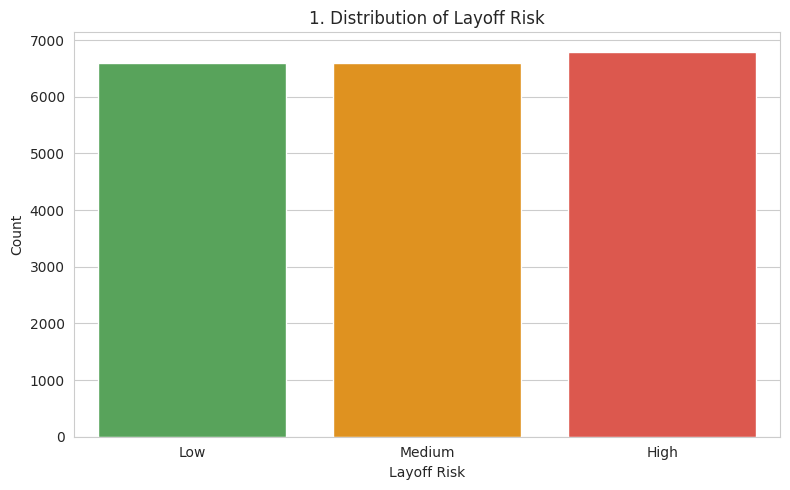

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Layoff_Risk', order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Distribution of Layoff Risk')
plt.xlabel('Layoff Risk')
plt.ylabel('Count')
show(); plot_no += 1


### 4.2 Age Distribution of Employees
A histogram with KDE shows whether age is normally distributed or skewed.

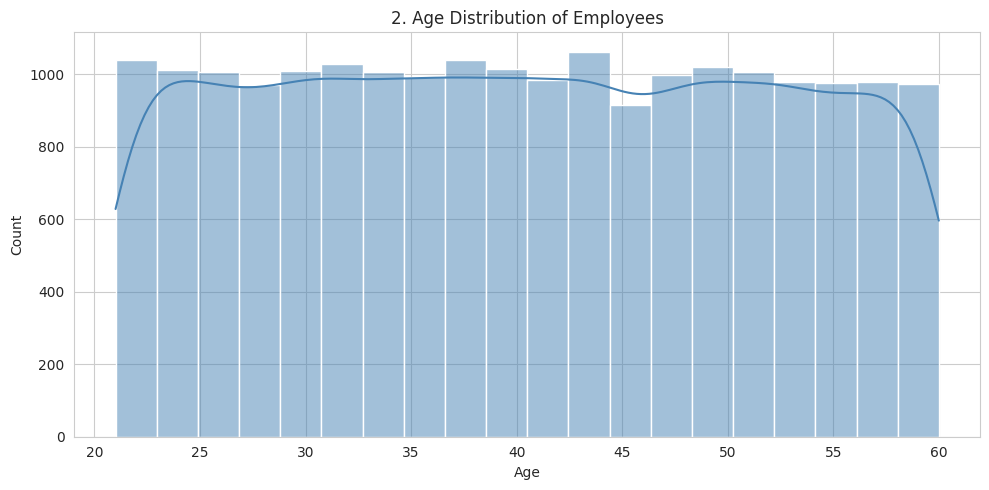

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'], kde=True, color='steelblue', bins=20)
plt.title(f'{plot_no}. Age Distribution of Employees')
plt.xlabel('Age')
plt.ylabel('Count')
show(); plot_no += 1


### 4.3 Age vs Layoff Risk
Boxplot — do older or younger employees face higher risk?

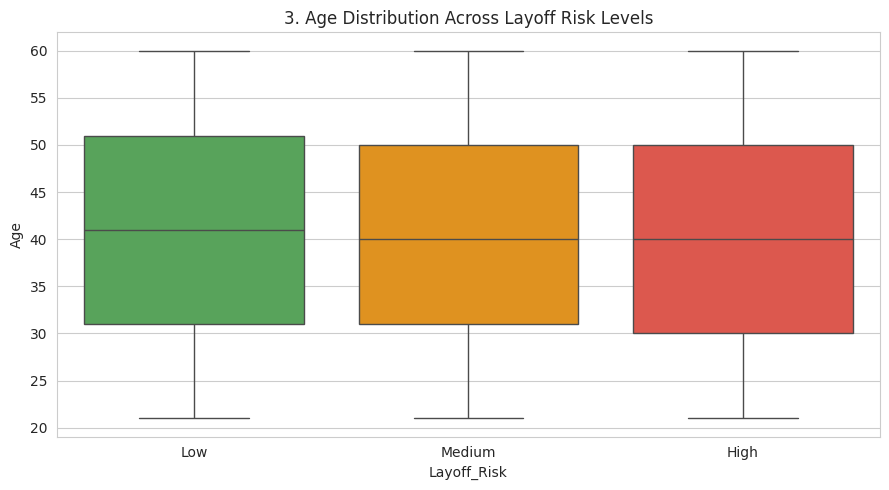

In [17]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='Age', order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Age Distribution Across Layoff Risk Levels')
show(); plot_no += 1


### 4.4 Years of Experience vs Layoff Risk
More experience might mean higher job security — let's verify.

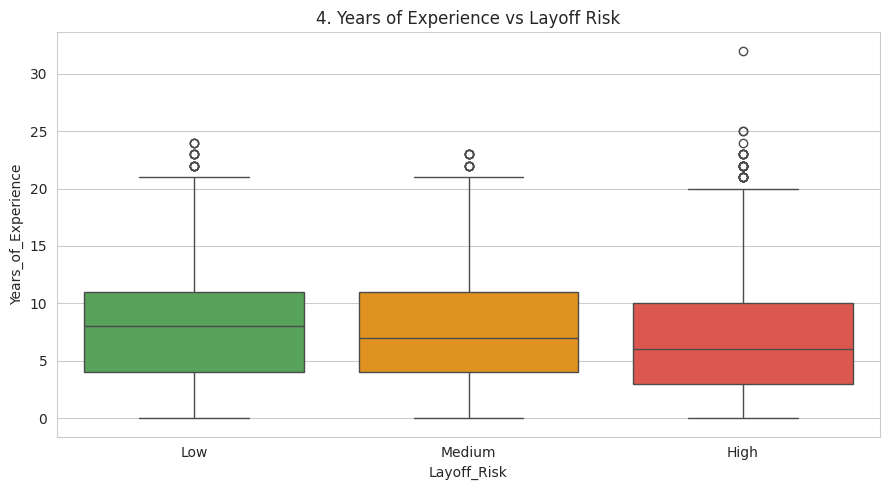

In [18]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='Years_of_Experience',
            order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Years of Experience vs Layoff Risk')
show(); plot_no += 1


### 4.5 Layoff Risk by Education Level
Does a higher degree protect workers from AI displacement?

<Figure size 1000x500 with 0 Axes>

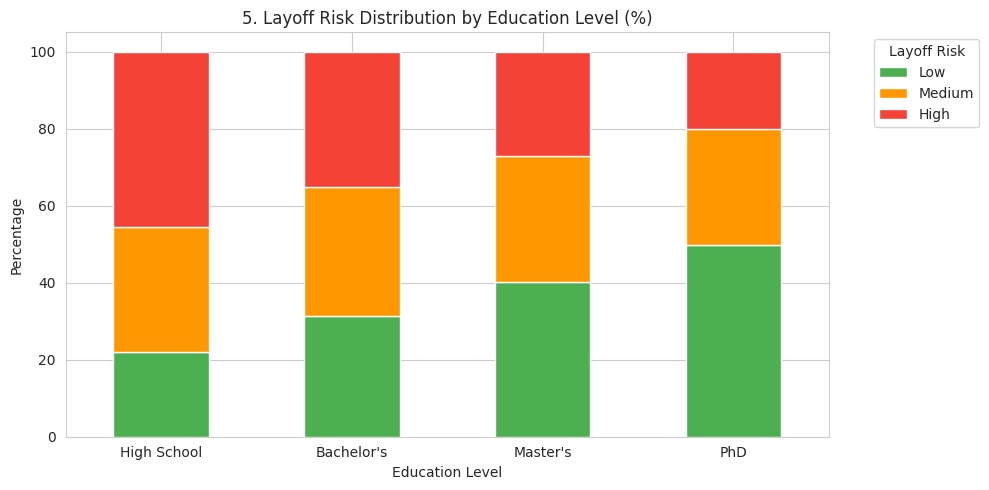

In [19]:
edu_order = ['High School', "Bachelor's", "Master's", 'PhD']
plt.figure(figsize=(10, 5))
risk_edu = pd.crosstab(df['Education_Level'], df['Layoff_Risk'], normalize='index') * 100
risk_edu = risk_edu[RISK_ORDER].loc[edu_order]
risk_edu.plot(kind='bar', stacked=True, color=RISK_COLORS, figsize=(10, 5))
plt.title(f'{plot_no}. Layoff Risk Distribution by Education Level (%)')
plt.xlabel('Education Level')
plt.ylabel('Percentage')
plt.legend(title='Layoff Risk', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
show(); plot_no += 1


### 4.6 Layoff Risk Across Industries
Which industries are most at risk from AI automation?

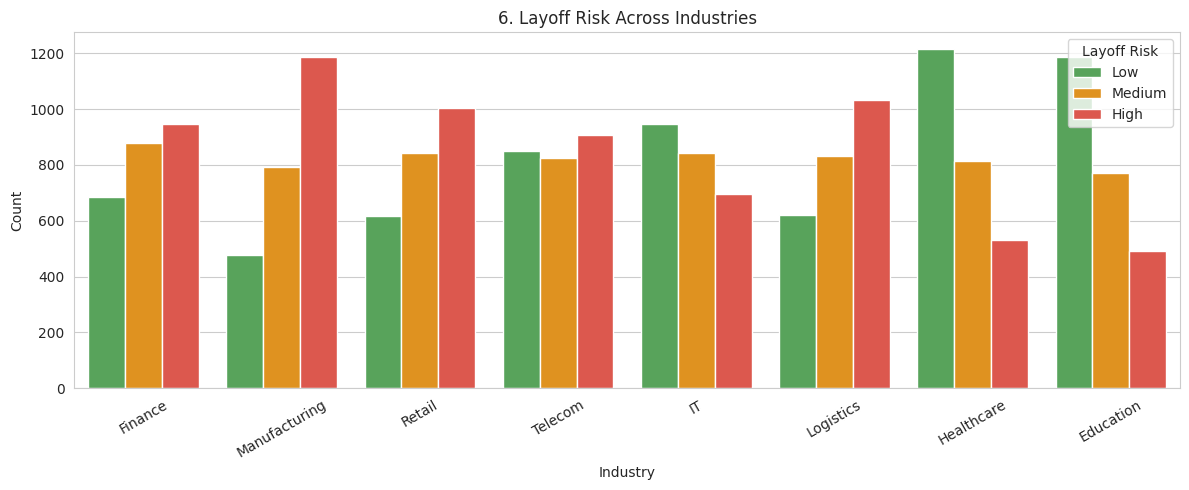

In [20]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Industry', hue='Layoff_Risk',
              hue_order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Layoff Risk Across Industries')
plt.xlabel('Industry')
plt.ylabel('Count')
plt.legend(title='Layoff Risk')
plt.xticks(rotation=30)
show(); plot_no += 1


### 4.7 Top Job Roles by Layoff Risk
Heat-map of how high-risk each job role is.

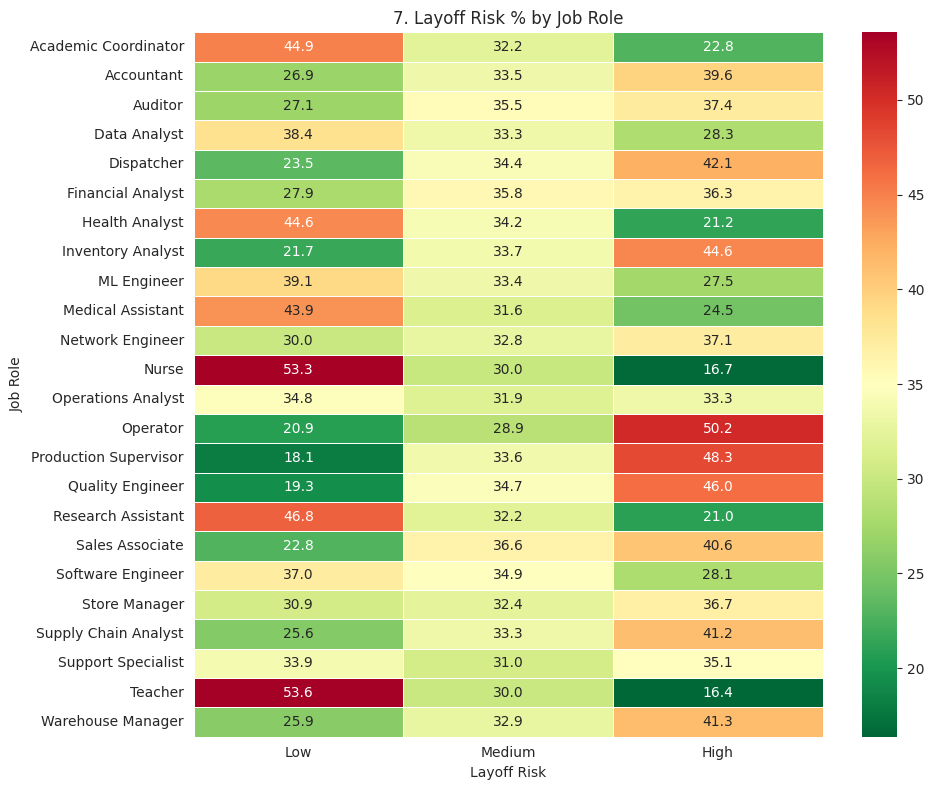

In [21]:
role_risk = pd.crosstab(df['Job_Role'], df['Layoff_Risk'])[RISK_ORDER]
role_risk_pct = role_risk.div(role_risk.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 8))
sns.heatmap(role_risk_pct, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=0.5)
plt.title(f'{plot_no}. Layoff Risk % by Job Role')
plt.xlabel('Layoff Risk')
plt.ylabel('Job Role')
show(); plot_no += 1


### 4.8 Routine Task Percentage vs Layoff Risk
The more routine a job, the easier it is to automate — does this show in the data?

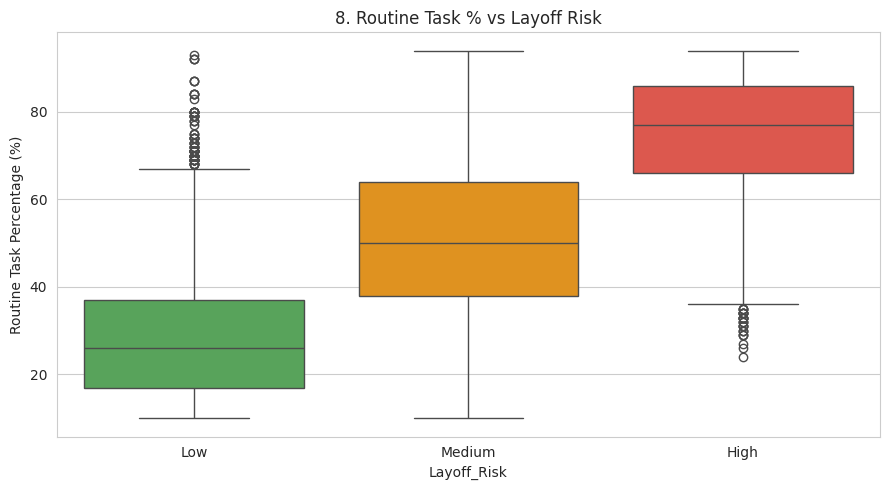

In [22]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='Routine_Task_Percentage',
            order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Routine Task % vs Layoff Risk')
plt.ylabel('Routine Task Percentage (%)')
show(); plot_no += 1


### 4.9 Creativity Requirement vs Layoff Risk
Creativity is hard to automate — higher creativity should correlate with lower risk.

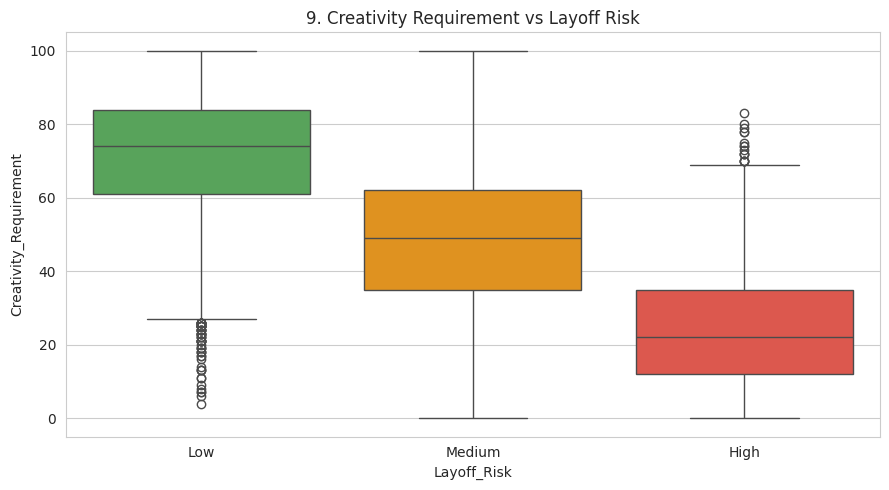

In [23]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='Creativity_Requirement',
            order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Creativity Requirement vs Layoff Risk')
show(); plot_no += 1


### 4.10 Tasks Automated Percentage vs Layoff Risk
How much of the job is already automated? A key signal.

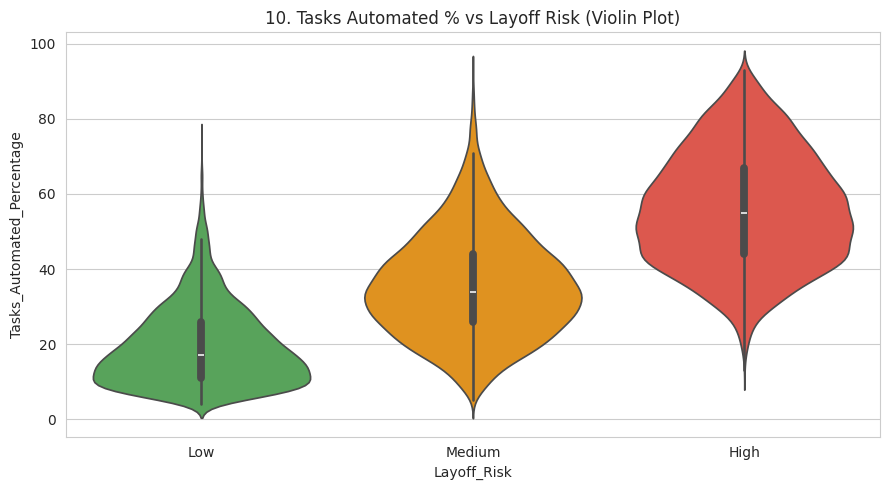

In [24]:
plt.figure(figsize=(9, 5))
sns.violinplot(data=df, x='Layoff_Risk', y='Tasks_Automated_Percentage',
               order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Tasks Automated % vs Layoff Risk (Violin Plot)')
show(); plot_no += 1


### 4.11 AI Adoption Level vs Layoff Risk
Higher company-level AI adoption might mean more displacement.

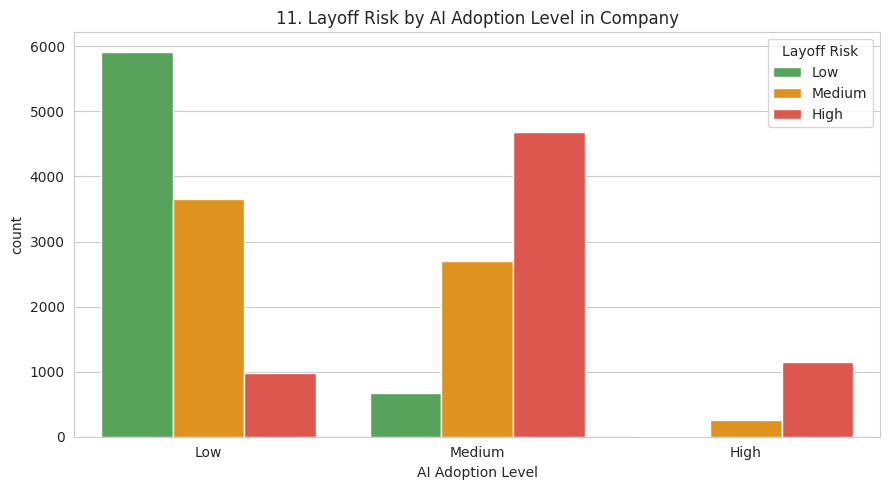

In [25]:
ai_order = ['Low', 'Medium', 'High']
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='AI_Adoption_Level', hue='Layoff_Risk',
              order=ai_order, hue_order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Layoff Risk by AI Adoption Level in Company')
plt.xlabel('AI Adoption Level')
plt.legend(title='Layoff Risk')
show(); plot_no += 1


### 4.12 Number of AI Tools Used vs Layoff Risk
Using more AI tools might indicate adaptability — or replacability.

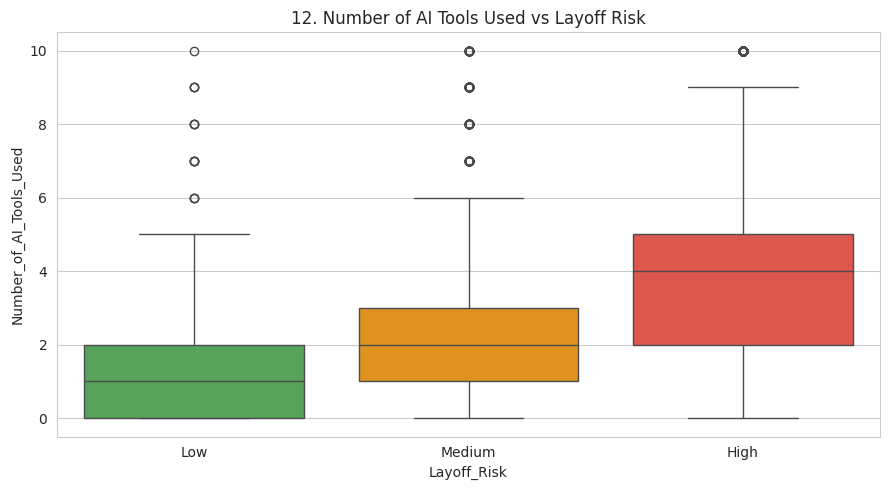

In [26]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='Number_of_AI_Tools_Used',
            order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Number of AI Tools Used vs Layoff Risk')
show(); plot_no += 1


### 4.13 AI Training Hours vs Layoff Risk
Employees investing in AI training may be upskilling to reduce their risk.

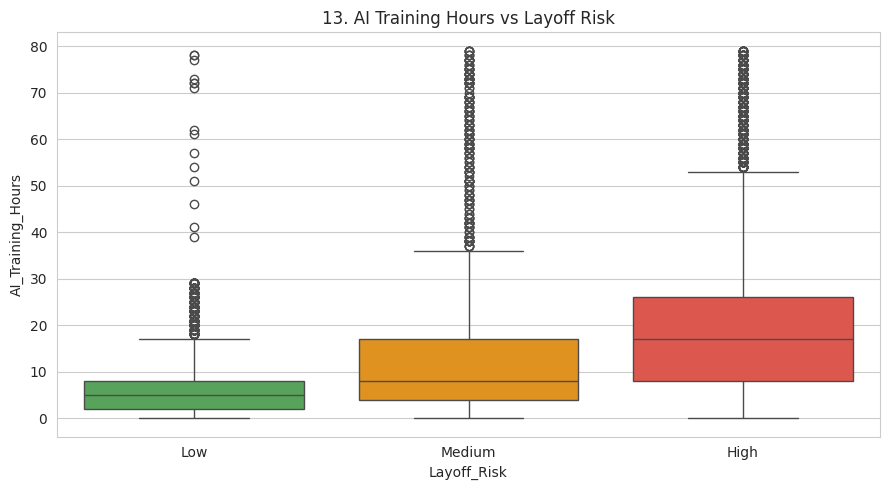

In [27]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Layoff_Risk', y='AI_Training_Hours',
            order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. AI Training Hours vs Layoff Risk')
show(); plot_no += 1


### 4.14 Layoff Risk by Company Size
Do large companies lay off more than small ones?

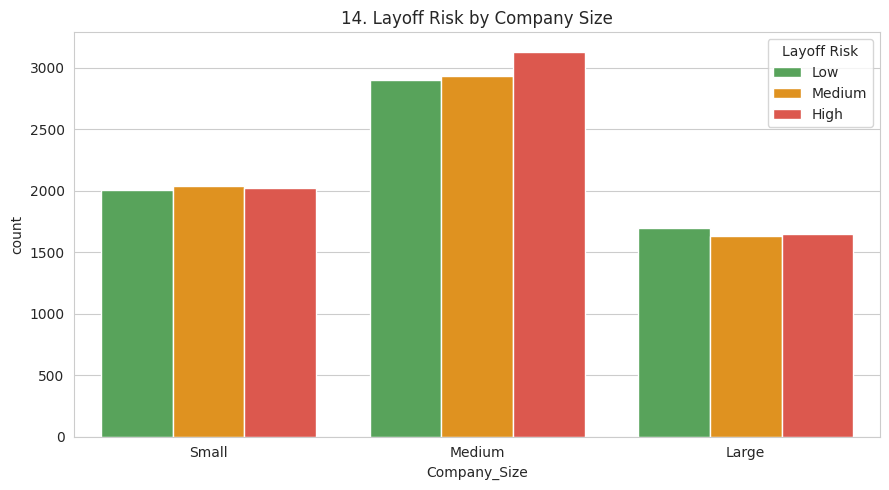

In [28]:
size_order = ['Small', 'Medium', 'Large']
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Company_Size', hue='Layoff_Risk',
              order=size_order, hue_order=RISK_ORDER, palette=RISK_COLORS)
plt.title(f'{plot_no}. Layoff Risk by Company Size')
plt.legend(title='Layoff Risk')
show(); plot_no += 1


### 4.15 Correlation Heatmap (Numeric Features)
Which numeric features are most correlated with each other?

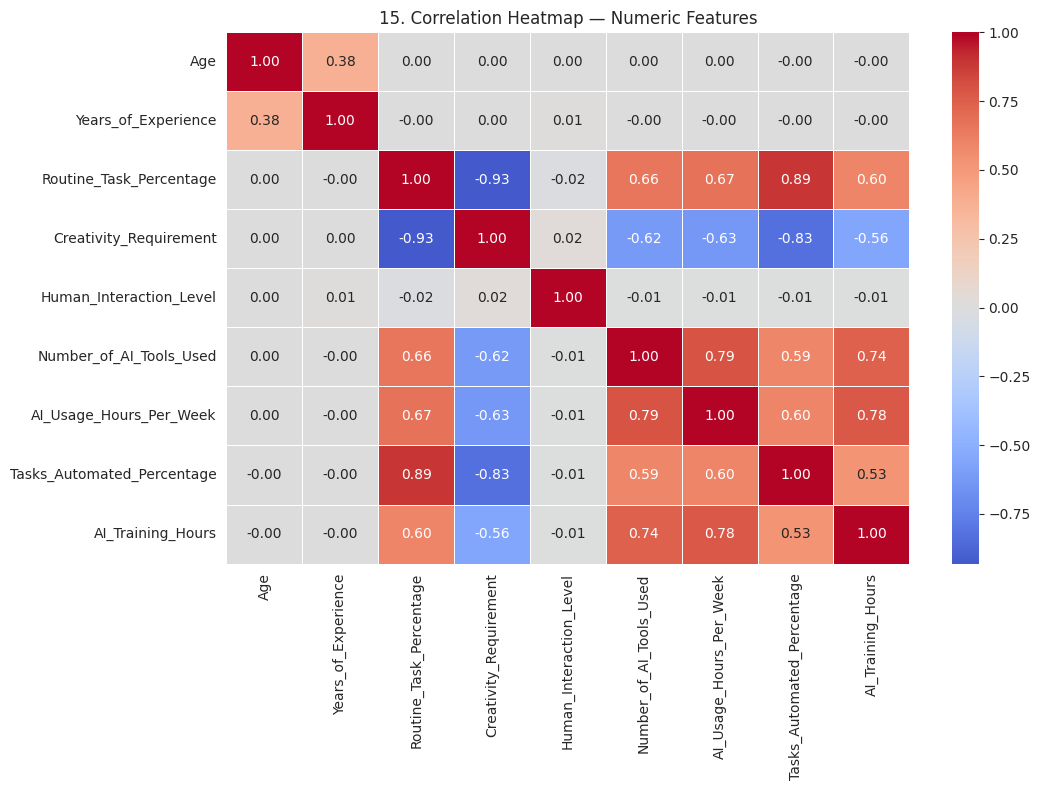

In [29]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr().round(2),
            annot=True, cmap='coolwarm', center=0,
            linewidths=0.5, fmt='.2f')
plt.title(f'{plot_no}. Correlation Heatmap — Numeric Features')
show(); plot_no += 1


### 4.16 Pairplot — Key Numeric Features Coloured by Layoff Risk
A scatter-matrix to spot patterns across the most important numeric features.

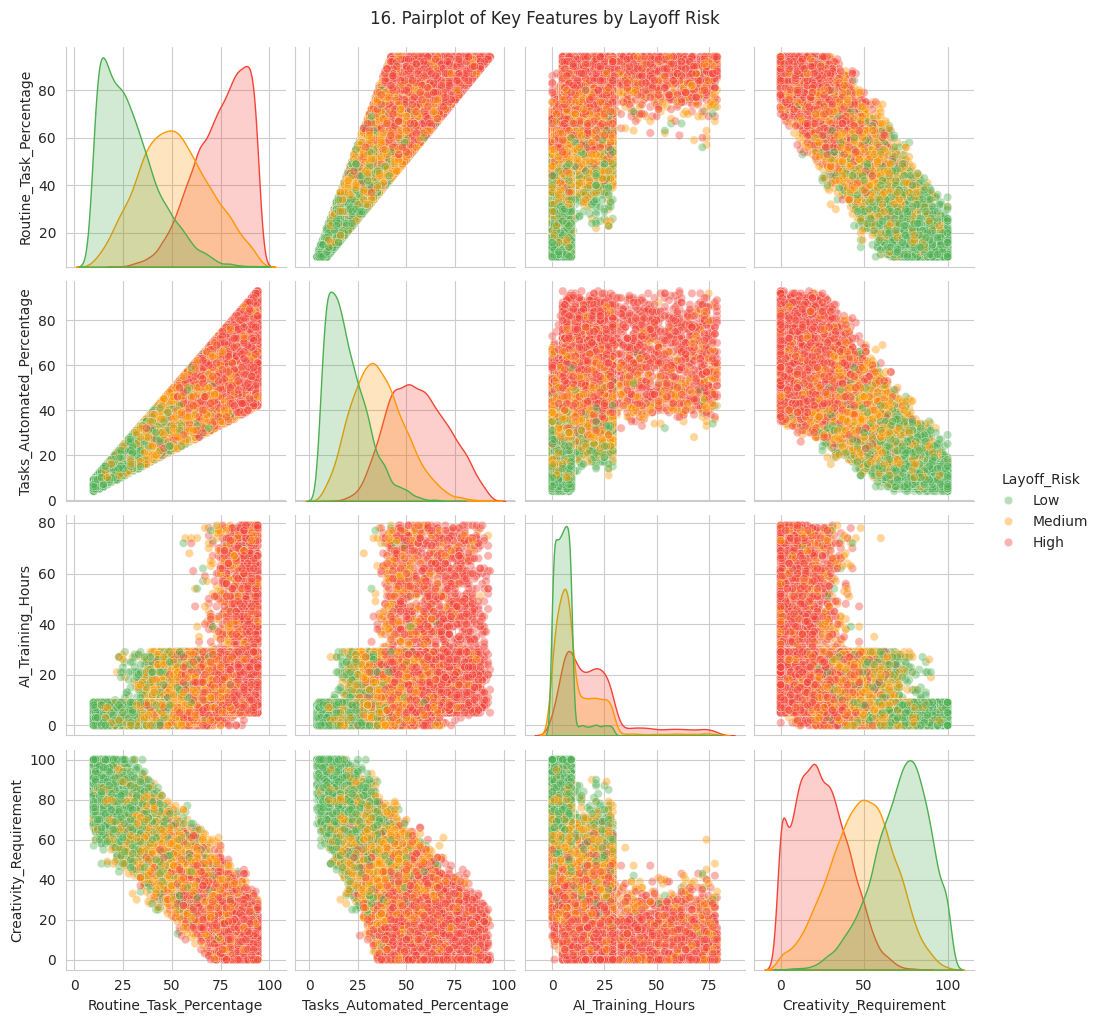

In [30]:
key_features = ['Routine_Task_Percentage', 'Tasks_Automated_Percentage',
                'AI_Training_Hours', 'Creativity_Requirement', 'Layoff_Risk']

sns.pairplot(df[key_features], hue='Layoff_Risk',
             hue_order=RISK_ORDER, palette=dict(zip(RISK_ORDER, RISK_COLORS)),
             plot_kws={'alpha': 0.4})
plt.suptitle(f'{plot_no}. Pairplot of Key Features by Layoff Risk', y=1.02)
plt.show(); plot_no += 1


## 5. Key Takeaways

Based on the EDA above, here are the main insights from this dataset:

| # | Insight |
|---|---------|
| 1 | **Target is balanced** — roughly 1/3 of records fall into each risk category (Low / Medium / High) |
| 2 | **Routine Task % and Tasks Automated %** are among the strongest signals for high layoff risk |
| 3 | **Creativity and Human Interaction** correlate with lower layoff risk — roles requiring these are harder to automate |
| 4 | **AI Training Hours** show that employees proactively upskilling tend to land in the lower-risk bucket |
| 5 | **Education level** matters — PhD and Master's holders show relatively lower high-risk proportions |
| 6 | **Industry and Job Role** vary significantly in their risk profiles — Finance and Logistics show higher risk, Healthcare lower |
| 7 | **Company AI adoption level** amplifies risk: high adoption + high routine tasks = strong high-risk signal |

---

### Next Steps 🚀
- **Feature Engineering** — encode categorical columns, create interaction features
- **Model Training** — try Logistic Regression, Random Forest, XGBoost for classification
- **Model Evaluation** — accuracy, F1-score, confusion matrix


Support This Notebook

If you found this notebook helpful, informative, or useful for your learning journey, please consider giving it an upvote. Your support motivates me to create and share more data science and machine learning content with the community.

Thank you for your time and happy learning! 🚀